In [78]:
# Step 2

dataset_path = './dpl_images'

In [79]:
# Step 3

import importlib
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
import ear_extraction
importlib.reload(ear_extraction)
from ear_extraction import extract_ear_region


In [80]:
# Step 4

image_extensions = {'.jpg', '.jpeg', '.png', '.bmp'}
records = []

for class_dir in sorted(Path(dataset_path).iterdir()):
    if class_dir.is_dir():
        for image_path in sorted(class_dir.iterdir()):
            if image_path.suffix.lower() in image_extensions:
                records.append({
                    'filename': str(image_path),
                    'class_name': class_dir.name,
                })

dataset_df = pd.DataFrame(records)
class_order = ['b_earrings', 'b_no_earrings', 'g_earrings', 'g_no_earrings']

train_parts = []
validation_parts = []

for class_name, class_df in dataset_df.groupby('class_name', sort=False):
    validation_df = class_df.sample(frac=0.2, random_state=42)
    train_df = class_df.drop(validation_df.index)
    train_parts.append(train_df)
    validation_parts.append(validation_df)

train_df = pd.concat(train_parts).sample(frac=1, random_state=42).reset_index(drop=True)
validation_df = pd.concat(validation_parts).sample(frac=1, random_state=42).reset_index(drop=True)


In [81]:
# Step 5

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.4,
    brightness_range=[0.6, 1.4],
    preprocessing_function=extract_ear_region,
)

train_data = train_datagen.flow_from_dataframe(
    train_df,
    x_col='filename',
    y_col='class_name',
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical',
    classes=class_order,
    shuffle=True,
)

print(train_data.class_indices)


Found 320 validated image filenames belonging to 4 classes.
{'b_earrings': 0, 'b_no_earrings': 1, 'g_earrings': 2, 'g_no_earrings': 3}


In [82]:
# Step 6

validation_datagen = ImageDataGenerator(
    rescale=1./255,
    preprocessing_function=extract_ear_region,
)

validation_data = validation_datagen.flow_from_dataframe(
    validation_df,
    x_col='filename',
    y_col='class_name',
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical',
    classes=class_order,
    shuffle=False,
)


Found 80 validated image filenames belonging to 4 classes.


In [83]:
# Step 7

base_model = tf.keras.applications.MobileNetV2(
    include_top=False,
    weights='imagenet',
    input_shape=(128, 128, 3),
)
base_model.trainable = False

inputs = layers.Input(shape=(128, 128, 3))
x = layers.Rescaling(2.0, offset=-1.0)(inputs)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(len(class_order), activation='softmax')(x)

model = models.Model(inputs, outputs)


In [84]:
# Step 8

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)


In [85]:
# Step 9

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
)
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-6,
)

history = model.fit(
    train_data,
    epochs=20,
    validation_data=validation_data,
    callbacks=[early_stopping, reduce_lr],
)


Epoch 1/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 34s 3s/step - accuracy: 0.2937 - loss: 1.9742 - val_accuracy: 0.4000 - val_loss: 1.2079 - learning_rate: 1.0000e-04
Epoch 2/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 25s 3s/step - accuracy: 0.3219 - loss: 1.5580 - val_accuracy: 0.5875 - val_loss: 1.0260 - learning_rate: 1.0000e-04
Epoch 3/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 26s 3s/step - accuracy: 0.4500 - loss: 1.2675 - val_accuracy: 0.7625 - val_loss: 0.8590 - learning_rate: 1.0000e-04
Epoch 4/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 26s 3s/step - accuracy: 0.5188 - loss: 1.1599 - val_accuracy: 0.8250 - val_loss: 0.7636 - learning_rate: 1.0000e-04
Epoch 5/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 24s 2s/step - accuracy: 0.5813 - loss: 1.0344 - val_accuracy: 0.8250 - val_loss: 0.6912 - learning_rate: 1.0000e-04
Epoch 6/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 26s 3s/step - accuracy: 0.6187 - loss: 0.8877 - val_accuracy: 0.8125 - val_loss: 0.6397 - learning_rate: 1.0000e-04
Epoch 7/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 26s 3s/step - accuracy: 0.6469 - loss:

In [86]:
# Step 10
loss, accuracy = model.evaluate(validation_data)

print("Validation Accuracy:", accuracy)

3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.8750 - loss: 0.3909
Validation Accuracy: 0.875


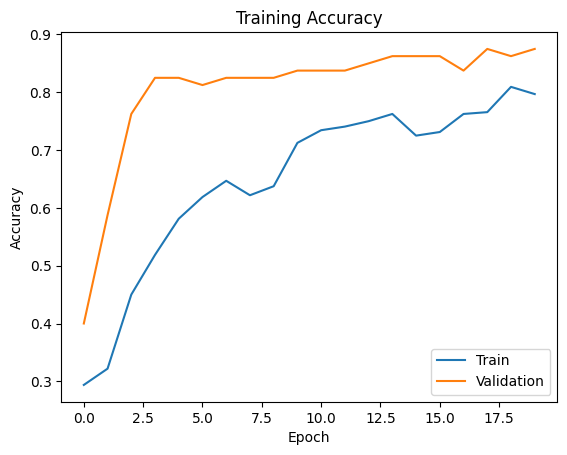

In [87]:
# Step 11
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Training Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'])

plt.show()

In [89]:
# Step 12
model.save('cnn_classifier.h5')